## STA 5737 Assignment 3 Hope Mullins

Set the working directory:

In [1]:
import os
os.chdir('C:/ucf_classes/sta_5735')

## Question 1

### part 1)

In [2]:
from pymongo import MongoClient
from pymongo.server_api import ServerApi
import pandas as pd
import json
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, auc, classification_report

Let's begin by loading in our data "merged_json_ds.json", taken from https://www.kaggle.com/datasets/wilfriedw/resume-and-jd-data. Reading/loading it into a Python data structure will allow us to observe the contents in the file and all the nested aspects while maintaining the JSON structure.

In [3]:
with open("merged_json_ds.json", "r") as f:
    data = json.load(f)

Now, we should check what the type of the object is:

In [4]:
type(data)

list

Part of what makes JSON files so useful is that they can represent various data structures, such as strings, numbers, arrays, booleans, and nested objects. Given that the type of our data is a list, we recognize that it may contain nested elements of many types. It would be useful to explore the exact structure of our data, as well as key features of it. First, let's observe just the first element of our data, to get an idea of what it contains.

In [5]:
pprint(data[0])

{'input': {'job_description': {'company_details': 'Growing VC-backed Start-Up '
                                                  'in the US with a diverse '
                                                  'and inclusive culture, '
                                                  'where collaboration, '
                                                  'flexibility and acceptance '
                                                  'are the key focuses.',
                               'company_name': 'Your Remote Tech Recruiter',
                               'eduation': None,
                               'job_responsibilities': ['Owning the entire '
                                                        'product lifecycle '
                                                        'from end-to-end.',
                                                        'Taking on elements of '
                                                        'a product management '
                     

Opening this in the text editor reveals that this list is semi-deeply nested. To fully observe the structure of our data, I will utilize the Pandas function json_normalize(), which flattens the data into a tabular format, making it easier to analyze, manipulate, and read. The nested elements become columns in a DataFrame.

In [6]:
flat_data = pd.json_normalize(data)

In [7]:
flat_data.head()

,input.resume.name,input.resume.email,input.resume.phone,input.resume.linkedin,input.resume.github,input.resume.portfolio,input.resume.summary,input.resume.skill_section,input.resume.education,input.resume.work_experience,...,input.resume.technical_skills.Hardware and Networking,input.resume.highlights,input.resume.languages,input.resume.Security Clearance,input.resume.technical_skills_experience,input.resume.affiliations,input.resume.Executive Summary,input.resume.interests,input.resume.volunteer_experience,input.resume.additional_information
0,None,None,None,None,None,None,Dedicated Information Assurance Professional w...,"[Enterprise platforms, Knowledge of Product Li...",[{'school': 'Florence Darlington Technical Sch...,"[{'name': 'Company Name', 'role': 'Information...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,None,None,None,None,None,Dedicated Information Assurance Professional w...,"[Enterprise platforms, Knowledge of Product Li...",[{'school': 'Florence Darlington Technical Sch...,"[{'name': 'Company Name', 'role': 'Information...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,None,None,None,None,None,Dedicated Information Assurance Professional w...,"[Enterprise platforms, Knowledge of Product Li...",[{'school': 'Florence Darlington Technical Sch...,"[{'name': 'Company Name', 'role': 'Information...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,None,None,None,None,None,Dedicated Information Assurance Professional w...,"[Enterprise platforms, Knowledge of Product Li...",[{'school': 'Florence Darlington Technical Sch...,"[{'name': 'Company Name', 'role': 'Information...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,None,None,None,None,None,None,Dedicated Information Assurance Professional w...,"[Enterprise platforms, Knowledge of Product Li...",[{'school': 'Florence Darlington Technical Sch...,"[{'name': 'Company Name', 'role': 'Information...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


With our data structured in this manner, we can note some aspects about it. First, as seen from using the head() function, much of our data contains missing values. This will need to be cleaned before importing our data into a MongoDB database. Next, we might use the info() function to see how much null data there is throughout the entire dataset.

In [8]:
flat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20880 entries, 0 to 20879
Data columns (total 33 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   input.resume.name                                      12528 non-null  object
 1   input.resume.email                                     1392 non-null   object
 2   input.resume.phone                                     1740 non-null   object
 3   input.resume.linkedin                                  1740 non-null   object
 4   input.resume.github                                    1392 non-null   object
 5   input.resume.portfolio                                 1218 non-null   object
 6   input.resume.summary                                   20358 non-null  object
 7   input.resume.skill_section                             20706 non-null  object
 8   input.resume.education                                 2

Looking at this, there is more to note. Every column name begins with "input", revealing that all the content is stored under just one key. Moreover, the next aspect of our nested list consists of two keys: "resume" and "job_description". Past that, of the thirty-three columns, there are a variety of keys in both the resume and job_description components, with seven of those keys relating to the job and the remaining keys related to the resume.

Furthermore, we see that of 20,880 rows, the majority of columns contain null values. Let's calculate the percentage of null values within each column.

In [9]:
print("Percentage of Missing Values Within Each Column:")
missing = flat_data.isna().mean() * 100
print(missing)

Percentage of Missing Values Within Each Column:
input.resume.name                                        40.000000
input.resume.email                                       93.333333
input.resume.phone                                       91.666667
input.resume.linkedin                                    91.666667
input.resume.github                                      93.333333
input.resume.portfolio                                   94.166667
input.resume.summary                                      2.500000
input.resume.skill_section                                0.833333
input.resume.education                                    0.000000
input.resume.work_experience                              0.000000
input.resume.projects                                    10.000000
input.resume.certifications                              10.000000
input.resume.achievements                                 8.333333
input.job_description.job_title                           0.000000
input.job_des

To reiterate, only a few of the columns have some information in every row; most of these columns are missing a good chunk of values, with many even missing close to 100%. Because Mongo allows documents to have different structures (making it more flexible of a database than SQL), we can remove keys with empty values from the dictionaries in this dataset before inserting them into MongoDB. Because MongoDB stores JSON files using a format known as BSON (binary JSON), we should use our originally loaded dataset and not the flattened structure, as flattening our data converted it to a DataFrame.

The function below accomplishes our goal of removing keys with empty values by recursively checking each item in the data. For a dictionary, it keeps only the key-value pairs if the value is not empty. Otherwise, it is removed. This ensures that all our documents are kept in the database, but it reduces the size and unnecessary information that is currently in our file.

In [10]:
def clean(dictionary):
    return {k: v for k, v in dictionary.items() if v not in [None, '', [], {}]}

for record in data:
    if 'resume' in record['input']:
        record['input']['resume'] = clean(record['input']['resume'])
    if 'job_description' in record['input']:
        record['input']['job_description'] = clean(record['input']['job_description'])

### part 2)

Having explored and cleaned the data, we can now insert it into a MongoDB database. I will do so using the cloud. Begin by connecting to a MongoDB cluster with the specified URI. Databases and collections need not be created in advance, but the following code creates/accesses the database "profiles" and the connection "data". (Note: The username and password may need to be adjusted in order for the user to access the MongoDB database).

In [ ]:
uri = "mongodb+srv://hopemullins:<dbpassword>@cluster0.5s6taet.mongodb.net/?retryWrites=true&w=majority&appName=Cluster0"
client = MongoClient(uri, server_api=ServerApi('1'))

try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)

Pinged your deployment. You successfully connected to MongoDB!


Create/access the database:

In [12]:
db = client["profiles"]

Create/access the connection:

In [13]:
collection = db["resume_data"]

Insert the data into the resume_data collection using insert_many():

In [ ]:
collection.insert_many(data)

With this, we see we have successfully placed the data in the MongoDB database. (Note: there is no output because I accidentally restarted the kernel and cleared all the output. Running the above line again would've inserted the same data into the collection, resulting in duplicate values). 

### part 3)

Now we will count the number of documents that are in the collection, which is easily accomplished using the count_documents() function provided by PyMongo. Because we want to count all documents, we include "{}" within the parentheses of our function because it is an empty query (in other words, the function takes a query dictionary)

In [14]:
num_doc = collection.count_documents({})
print("Number of Documents in MongoDB Collection:", num_doc)

Number of Documents in MongoDB Collection: 20880


This is the same number of observations that we had when we originally loaded the data into Python, thus proving that all the documents were successfully placed within the database.

### part 4)

Next, we would like to perform some summary statistics for the "skills" key, specifically the average number of skills, max number of skills, and the median number of skills. Moreover, we would like to plot the distribution to get a visual of the shape and spread of the data, as well as the frequency of values.

To get the numerical values, we first need the number of skills listed in each document. Recall that a good amount of the observations regarding the "skills" key were missing and thus not every document will have that key. Therefore, we need to specify to count the number of skills in each document, given that the key is within the document. Additionally, because the "skills" key is nested within two other keys ("input" and "resume"), we need to loop through those keys as well to ensure we're checking each row for the nested object.

In [15]:
num_skills = [len(doc["input"]["resume"]["skills"]) for doc in collection.find() if "input" in doc and "resume" in doc["input"] and "skills" in doc["input"]["resume"]]

In [16]:
avg_skills = np.mean(num_skills)
max_skills = np.max(num_skills)
median_skills = np.median(num_skills)

print(f"Total resumes processed: {len(num_skills)}")
print(f"Average number of skills: {avg_skills:.2f}")
print(f"Maximum number of skills: {max_skills}")
print(f"Median number of skills: {median_skills}")

Total resumes processed: 1740
Average number of skills: 35.20
Maximum number of skills: 92
Median number of skills: 36.0


From this, we see that, of the documents containing the "skills" key, the average number of skills included was about 35 skills, with the median being very close to that at 36 skills. The maximum number of skills listed included within a document was 92, demonstrating a wide range of the number of skills listed within a document (considering the minimum number of skills that could be listed is 0).

Now, we should plot the distribution:

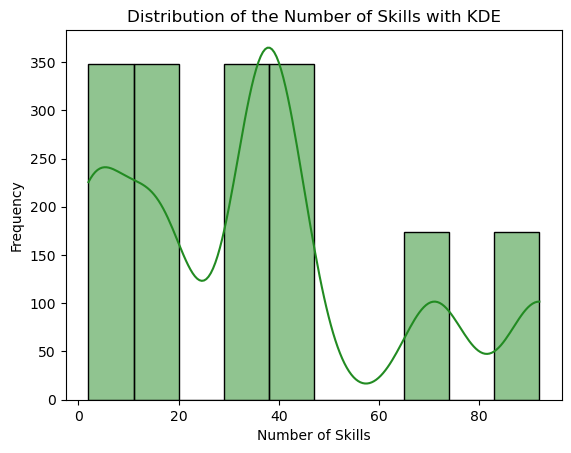

In [17]:
sns.histplot(num_skills, kde=True, bins=10, color='forestgreen', edgecolor='black')
plt.title("Distribution of the Number of Skills with KDE")
plt.xlabel("Number of Skills")
plt.ylabel("Frequency")
plt.show()


From this, we clearly see the variation in the number of skills listed in a resume. If we increase the number of bins in our histogram, we might see this variation more clearly.

Plotted with 50 bins:

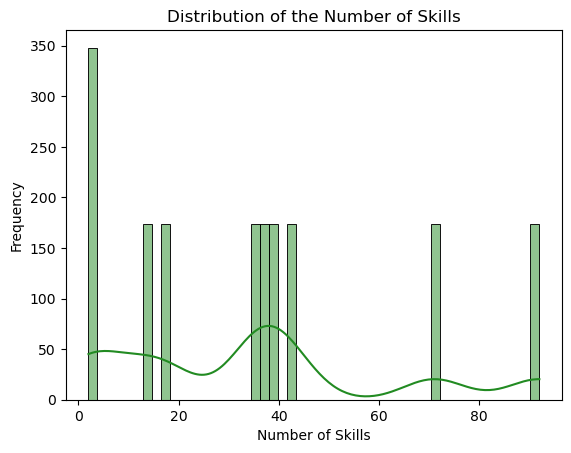

In [18]:
sns.histplot(num_skills, kde = True, bins = 50, color = 'forestgreen', edgecolor = 'black')
plt.title("Distribution of the Number of Skills")
plt.xlabel("Number of Skills")
plt.ylabel("Frequency")
plt.show()

Plotted with 100 bins:

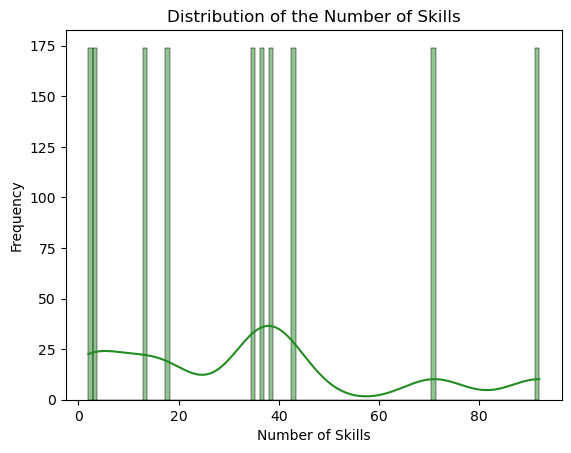

In [19]:
sns.histplot(num_skills, kde = True, bins = 100, color = 'forestgreen', edgecolor = 'black')
plt.title("Distribution of the Number of Skills")
plt.xlabel("Number of Skills")
plt.ylabel("Frequency")
plt.show()

### part 5)

Next, let's plot the distribution for the number of words in a resume. Again, we will need to count the number of words in each document, given that the key is in each document, and because the "resume" key is nested within the "input" key, we need to loop through "input" as we did previously. However, this is a bit more complicated than before, as each "resume" key contains various data structures. We would like to be able to count within each data type, whether it be a string, a list, a nested list, a dictionary, or a nested dictionary. Therefore, it is important that we flatten all items within the "resume" key of a document into a single string. 

The following function does so. If the value found is a string, then that string is returned (as it needs no more processing). If the value found is a list, the text function is applied to each value in the list and the results are joined into a string, separated by a space. On that note, if the list contains nested lists or dictionaries, the function recurses into those as well. If the value found is a dictionary, then similarly the function is applied to each value in the dictionary and the results are also joined into a single string, separated by a space (note that the .values() method ensures the dictionary key is not included as a word). Finally, if the input is neither a string, nor a list, nor a dictionary, an empty string will be returned. 

In [20]:
def text(value):
    if isinstance(value, str):
        return value
    elif isinstance(value, list):
        return ' '.join(text(i) for i in value)
    elif isinstance(value, dict):
        return ' '.join(text(v) for v in value.values())
    return ''

With this function, we may then loop through each document in the collection, returning/processing only the "input.resume" field. If the resume is a dictionary (as it should be based on what we observed when we explored the data), then the text() function is applied to the dictionary, concatenating all the text into a single string and storing it. The stored text is then split into a list of words, which are then counted. The word_count for the document is then added the word_counts list, and at the end of the loop, the word_counts list should contain the number of words for each resume document. 

In [21]:
num_words = []
for doc in collection.find({}, {"input.resume": 1}):
    resume = doc.get("input", {}).get("resume")

    if isinstance(resume, dict):
        all = text(resume) 
        num_word = len(all.split())

    num_words.append(num_word)

Having looped through each document and counted up the words in each resume section, we can now calculate summary statistics and plot our distribution.

In [22]:
avg_words = np.mean(num_words)
max_words = np.max(num_words)
median_words = np.median(num_words)

print(f"Total resumes processed: {len(num_words)}")
print(f"Average number of words: {avg_words:.2f}")
print(f"Maximum number of words: {max_words}")
print(f"Median number of words: {median_words}")

Total resumes processed: 20880
Average number of words: 853.95
Maximum number of words: 2278
Median number of words: 763.5


On average, a resume includes approximately 854 words, with the median amount of words being somewhat lower than that at about 764. The maximum number of words is significantly larger, 2,278, which shows us there is great variation in the number of words included in a resume. This can be seen in the following distribution.

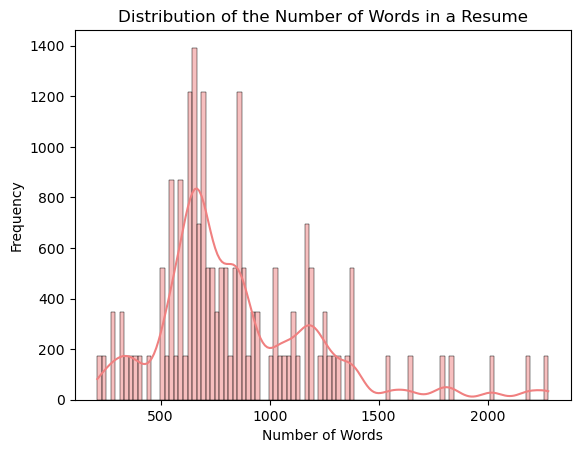

In [23]:
sns.histplot(num_words, kde = True, bins = 100, color = 'lightcoral', edgecolor = 'black')
plt.title("Distribution of the Number of Words in a Resume")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

From this visual, we see the great dispersion of word count within a resume. It is somewhat right-skewed, with a smaller number of individuals including more than 1,500 words on their resumes, but the majority of resumes have a word count falling within 500 to 1,500 words.

### part 6)

Next, we would like to find the top three words in the resume summaries. Because "summary" is found directly after the "resume" key, we can simply cycle through all the words in "input.resume.summary" and count the three most frequent words. This can be accomplished with Counter, a dictionary subclass, and re, a module that assists with pattern matching within strings. Beginning with an empty list, we can loop through each document in the MongoDB collection, searching for those that contain the field "summary". Then, we might use re to extract all words from the text and \w+ to match sequences of word characters, also using .lower() to convert all text to lowercase (so, for example, the word "A" and "a" are treated the same). The words will all be added to the empty list, and the Counter object counts the number of times each word appears in the list. The function .most_common() returns the top specified values (in our case, it would be 3).

In [24]:
all_words = []

for doc in collection.find():
    resume = doc.get("input", {}).get("resume", {})
    summary = resume.get("summary")

    if isinstance(summary, str):
        words = re.findall(r'\w+', summary.lower())
        all_words.extend(words)

word_freq = Counter(all_words)
top_3 = word_freq.most_common(3)

print("Top Three Most Frequent Words in Resume Summaries:")
for word, freq in top_3:
    print(f"{word}: {freq}")


Top Three Most Frequent Words in Resume Summaries:
and: 122148
in: 45414
to: 43500


From this, we see that the word "and" appears through the summary field of the resume section 122,148 times, "in" 45,414 times, and "to" 43,500 times. These words are extremely common and basic, so it makes sense that they would be among the most written/seen in a resume.

### part 7)

Finally, we can make a decision tree classifier to predict if the resume will have a LinkedIn or not. The job_description objects will likely not be of much importance in predicting this, but other aspects within the resume (name, email, phone, github, etc.) would be good features to include in our prediction model. We could classify some of these features by whether they are included or not, and others by how many of them are included (for example, the number of projects included in a resume). Looking back at our flattened data, we can observe which "columns" should be included.

In [25]:
flat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20880 entries, 0 to 20879
Data columns (total 33 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   input.resume.name                                      12528 non-null  object
 1   input.resume.email                                     1392 non-null   object
 2   input.resume.phone                                     1740 non-null   object
 3   input.resume.linkedin                                  1740 non-null   object
 4   input.resume.github                                    1392 non-null   object
 5   input.resume.portfolio                                 1218 non-null   object
 6   input.resume.summary                                   20358 non-null  object
 7   input.resume.skill_section                             20706 non-null  object
 8   input.resume.education                                 2

As already stated, those that fall within the "job_description" key will not have a significant role in this prediction process, so we can eliminate those features from our model. Moreover, many of the values within the "resume" key are missing. We can again calculate the percentages:

In [26]:
print("Percentage of Missing Values Within Each Column:")
missing = flat_data.isna().mean() * 100
print(missing)

Percentage of Missing Values Within Each Column:
input.resume.name                                        40.000000
input.resume.email                                       93.333333
input.resume.phone                                       91.666667
input.resume.linkedin                                    91.666667
input.resume.github                                      93.333333
input.resume.portfolio                                   94.166667
input.resume.summary                                      2.500000
input.resume.skill_section                                0.833333
input.resume.education                                    0.000000
input.resume.work_experience                              0.000000
input.resume.projects                                    10.000000
input.resume.certifications                              10.000000
input.resume.achievements                                 8.333333
input.job_description.job_title                           0.000000
input.job_des

Many fields, such as "additional_information", "volunteer_experience", and "email" are missing, meaning they will likely not be helpful for prediction. The only ones that contain a good chunk of data are "name", "summary", "skill_section", "education", "work_experience", "projects", "certifications, and "achievements", so we will use these as our independent variables. As it stands, "name" is the only one that could be coded as binary. The rest we can code based on the number of words (such as "summary", as it is most likely a string) or the number of elements (such as "certifications", as it is most likely a list). Note that we'll also include "linkedin" as a binary variable, as this is our target.

In [27]:
binary = ['name', 'linkedin']
non_binary = ['summary', 'skill_section', 'education', 'work_experience', 'projects', 'certifications', 'achievements']

Now, that we have these features identified, we need to loop through all the documents in our database collection, updating the information in our resumes to be numerical. For the values in our binary fields, we will classify them as 1 if they contain information and 0 otherwise. On the other hand, for those non-binary variables, we will count the number of words if the variable is a string and count the number of elements if the variable is a list. Alternatively, if a value is missing for the non-binary variables, it will be classified as a 0 as well. Beginning with an empty list, the following code accomplishes the above goals, looping through the rows and generating a DataFrame.

In [28]:
processed_data = []

for doc in collection.find():
    resume_data = doc.get("input", {}).get("resume", {})
    processed_row = {}
    
    for i in binary:
        value = resume_data.get(i, None)
        processed_row[i] = 1 if value else 0

    for i in non_binary:
        value = resume_data.get(i, None)
        if isinstance(value, list):
            processed_row[i] = len(value)
        elif isinstance(value, str):
            processed_row[i] = len(value.split())
        else:
            processed_row[i] = 0

    processed_data.append(processed_row)

processed_df = pd.DataFrame(processed_data)

Having done this, let's look at the first few rows of our data to ensure the process went smoothly:

In [29]:
processed_df.head()

,name,linkedin,summary,skill_section,education,work_experience,projects,certifications,achievements
0,0,0,39,34,1,3,0,0,0
1,0,0,39,34,1,3,0,0,0
2,0,0,39,34,1,3,0,0,0
3,0,0,39,34,1,3,0,0,0
4,0,0,39,34,1,3,0,0,0


Now we can define our target variable and other features:

In [30]:
X = processed_df.drop(columns=['linkedin'])
y = processed_df["linkedin"]

To make the decision tree, we need to first split our data into training and testing which can be done using train_test_split(). We'll use 70% of our data for training and the remaining 30% for testing.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Fit the decision tree based on the training data:

In [32]:
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Observe the performance using the testing data:

In [33]:
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.5f}")

Decision Tree Accuracy: 1.00000


In [34]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[5739    0]
 [   0  525]]


Therefore, the decision tree classifier perfectly predicted whether or not a resume would include a LinkedIn (there were no false positives nor false negatives). Sometimes this can indicate a problem, such as overfitting. However, due to the vast amount of data (20,880 rows) and the fact that the majority of resumes did not include a LinkedIn, it is possible that there were very specific factors indicating that an individual would include a LinkedIn. 

We might also identify which features are the most relevant when making predictions:

In [35]:
sorted_features_dt = sorted(zip(X.columns, dt.feature_importances_), key=lambda x: x[1], reverse=True)

print("Desicion Tree Feature Importance:")
for feat, imp in sorted_features_dt:
    print(feat, imp)

Desicion Tree Feature Importance:
achievements 0.3172542206717724
summary 0.30063462014667863
skill_section 0.29047510282628963
work_experience 0.0916360563552593
name 0.0
education 0.0
projects 0.0
certifications 0.0


From this, we see that "achievements", "summary", and "skill_section" all have somewhat similar importance, of about 32% 30% and 29%, respectively. Moreover, "work_experience" has an importance level of about 9%. The other variables we included for our prediction model were not considered important at all.

Next, let's plot the tree:

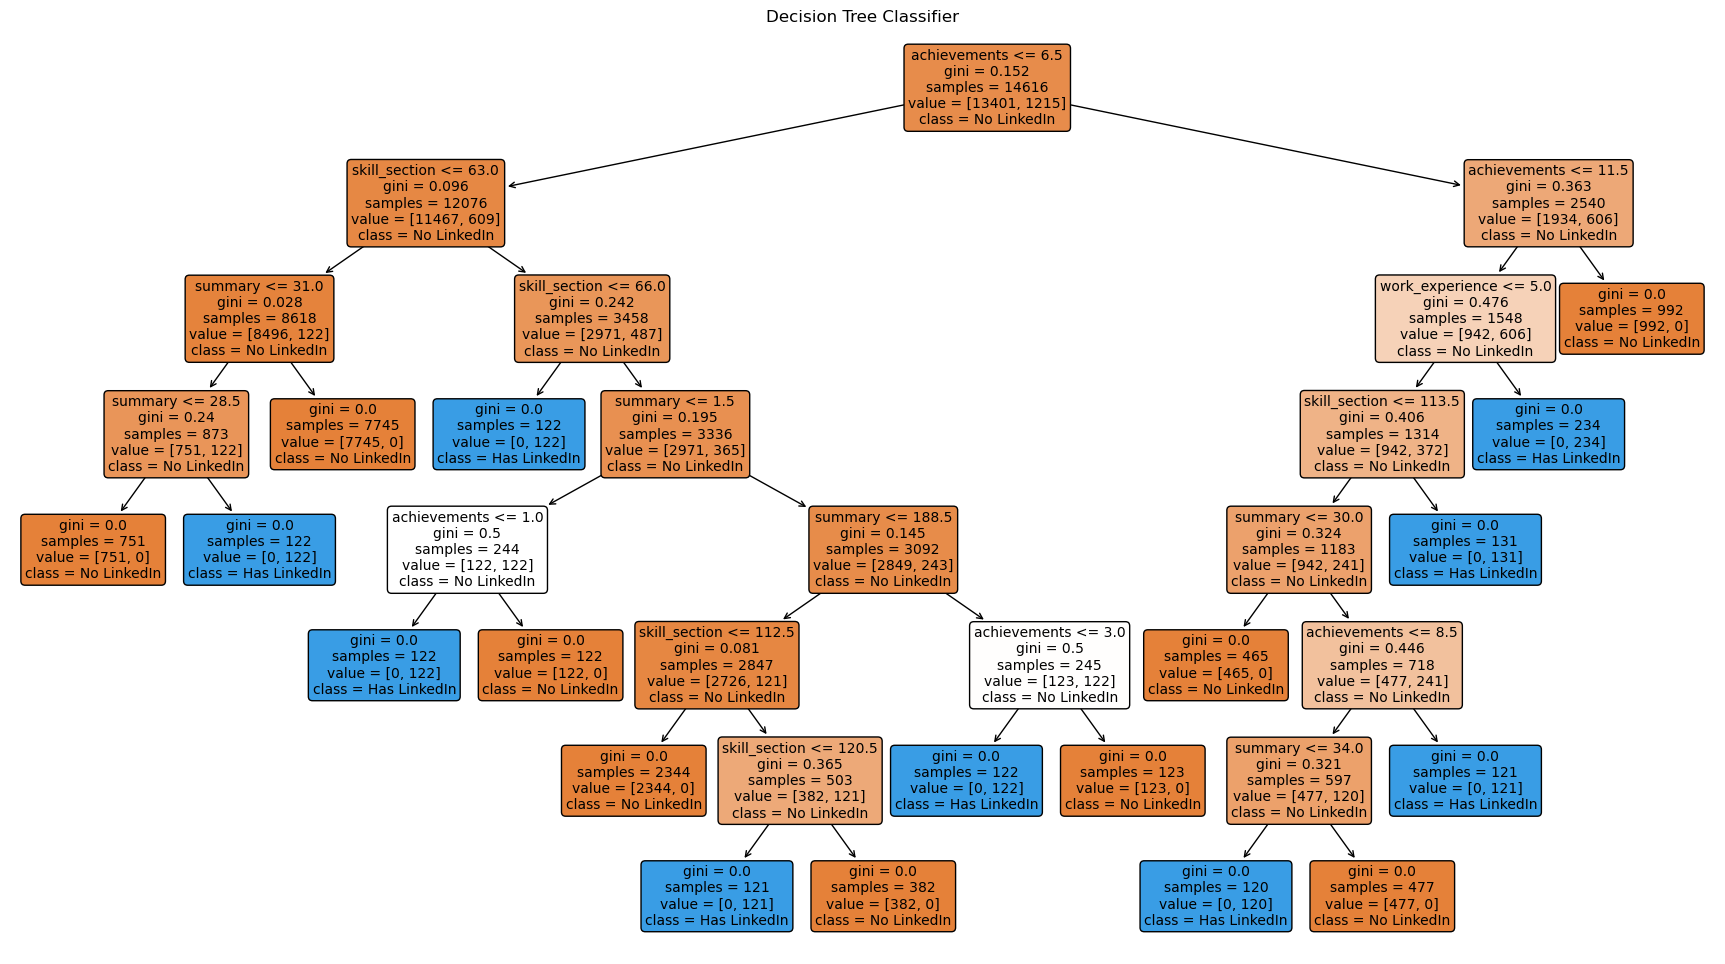

In [36]:
plt.figure(figsize=(22, 12))
plot_tree(dt, 
          feature_names = X.columns, 
          class_names = ["No LinkedIn", "Has LinkedIn"],
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title(f"Decision Tree Classifier")
plt.show()


Simply from looking at this, we see that our tree has a depth of 8. The node all the way at the top tells us the initial condition for splitting was that the number of achievements be less than 6.5, and that 14,616 resumes were used at this node. Because the majority of resumes do not have a LinkedIn, it leans toward "No LinkedIn" as the class. The tree continues to be split (from the left, based on skill_section, summary, and achievements again. From the right, based on number of achievements, work_experience, skill_section, summary, achievements, and then summary again). The gini index is a measure of impurity -- a lower score is preferable. Considering every split eventually results in a gini index equal to 0.0, we see that there is no ambiguity in classification.


## Question 2

In [91]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

### part 1)

Let's begin by loading in our data, teken from https://www.kaggle.com/datasets/bhavyadhingra00020/healthy-indian-recipes. This is just a csv file, so we can easily read this into Python as a DataFrame using the read_csv() function.

In [157]:
recipes = pd.read_csv("IndianHealthyRecipe.csv")

Look at the first few rows of the data:

In [158]:
recipes.head()

,Dish Name,Description,Spice,Prep Time,Views,Rating,Number of Votes,Serves,Dietary Info,Cook Time,Ingredients,Instructions
0,Pistachio chicken,Mild chicken in a creamy pistachio sauce,mild,Prep 10 mins,11604,4.1,18.0,4.0,['CONTAINS-NUTS'],30 mins,"1) 600g chicken thighs, cut into chunks\n2) 10...","1) Boil enough water to cover the pistachios, ..."
1,Tangy Fried Okra,Bhindi with Amchoor,medium,Prep 10 mins,49899,4.6,35.0,4.0,['VEGETARIAN'],15 mins,1) 500g okra\n2) 3 tbsp mustard oil\n3) 1 onio...,1) Wash and thoroughly dry the okra (kitchen r...
2,Healthy Chicken Korma,Chicken in Creamy Almond Sauce,mild,Prep 10 mins,115569,3.6,163.0,4.0,['CONTAINS-NUTS'],20 mins,1) 6-8 tbsp natural yoghurt\n2) 1 tsp turmeric...,1) Grind your whole spices in a spice grinder....
3,Brown Lentil Dhal,Sabut Masoor di Dhal,medium,Prep 10 mins,146798,3.7,87.0,4.0,['VEGETARIAN'],20 mins,1) 200g brown lentils\n2) Approx. 1L of water\n,1) Place the lentils in the pressure cooker wi...
4,Thari Wala Chicken,Healthy Chicken Curry,medium,Prep 10 mins,262696,3.5,343.0,4.0,['LACTOSE-FREE'],40 mins,1) 8 pieces of chicken (4 legs cut into thigh ...,"1) Skin the chicken, removing any excess fat.\..."


We see that there are a variety of columns related to these recipes, some being string variables and others being numerical. As we did in question 1, we might use the .info() function to better understand our data.

In [159]:
recipes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Dish Name        149 non-null    object 
 1   Description      149 non-null    object 
 2   Spice            145 non-null    object 
 3   Prep Time        148 non-null    object 
 4   Views            149 non-null    int64  
 5   Rating           149 non-null    float64
 6   Number of Votes  147 non-null    float64
 7   Serves           146 non-null    float64
 8   Dietary Info     149 non-null    object 
 9   Cook Time        134 non-null    object 
 10  Ingredients      149 non-null    object 
 11  Instructions     149 non-null    object 
dtypes: float64(3), int64(1), object(8)
memory usage: 14.1+ KB


From this, we see there are 12 columns and 149 rows within our dataset, consisting of four numerical variables (and the remaining eight variables are strings). A couple rows are missing information, but this is not a significant amount. Therefore, before we perform any analysis/manipulation of our data, let's remove the observations with NA values.

In [160]:
recipes = recipes.dropna()

Something else to observe is the number of unique values within each column.

In [161]:
unique = recipes.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
Dish Name          126
Description        122
Spice                4
Prep Time           12
Views              126
Rating              22
Number of Votes     78
Serves               6
Dietary Info        10
Cook Time           13
Ingredients        125
Instructions       125
dtype: int64


Many of these variables contain unique values in every row or almost every row (such as Dish Name, Description, Views, Ingredients, and Instructions). Those with less unique counts might be good to first observe, such as Spice, Prep Time, Serves, Dietary Info, and Cook Time. To see the actual unique values listed within each column, we may use the function .value_counts():

In [162]:
recipes['Spice'].value_counts()

Spice
medium    81
mild      24
hot       17
none       4
Name: count, dtype: int64

We may also visualize this with a histogram.

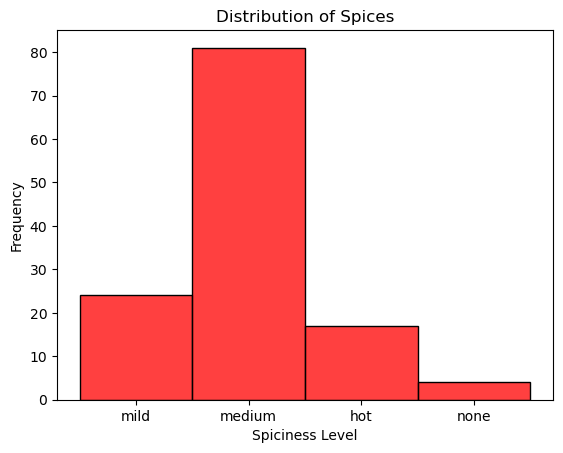

In [163]:
sns.histplot(recipes['Spice'], bins = 5, color = 'red', edgecolor = 'black')
plt.title("Distribution of Spices")
plt.xlabel("Spiciness Level")
plt.ylabel("Frequency")
plt.show()

From this, the majority of Indian recipes in this dataset are of about medium spiciness, while only a small number contain no spice. The remaining recipesare mild and hot.

Next, let's observe the distribution of Prep Time and Cook Time.

In [164]:
recipes['Prep Time'].value_counts()

Prep Time
Prep 10 mins          75
Prep 5 mins           28
Prep 20 mins           8
Prep 15 mins           3
Prep 30 mins           3
Prep 40 mins           3
Prep 2 hrs 10 mins     1
Prep 35 mins           1
Prep 2 days            1
Prep 1 hr 30 mins      1
Prep 12 hrs            1
Prep 25 mins           1
Name: count, dtype: int64

In [165]:
recipes['Cook Time'].value_counts()

Cook Time
20 mins        28
10 mins        23
30 mins        18
15 mins        17
40 mins        14
5 mins         10
1 hr            6
25 mins         3
50 mins         3
6 mins          1
5 hrs           1
35 mins         1
1 hr 5 mins     1
Name: count, dtype: int64

From this, we see the variation in both preparation time and cooking time that the recipes require. Later, when we've extracted just the numbers from these columns, we might visualize the distribution as well.

In [166]:
recipes['Serves'].value_counts()

Serves
4.0     93
6.0     22
2.0      5
8.0      3
12.0     2
1.0      1
Name: count, dtype: int64

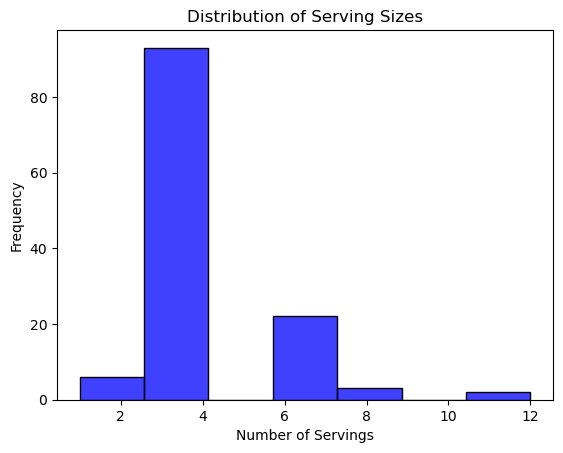

In [167]:
sns.histplot(recipes['Serves'], bins = 7, color = 'blue', edgecolor = 'black')
plt.title("Distribution of Serving Sizes")
plt.xlabel("Number of Servings")
plt.ylabel("Frequency")
plt.show()

Here, we see the distribution of serving sizes. As seen with the value_counts() function, the majority of recipes in this dataset serve 4 people (and this is seen in the above histogram as well). A smaller number of recipes serve 6 individuals, then 2, then 8, then 12, and finally one recipe serves a single person.

In [168]:
recipes['Dietary Info'].value_counts()

Dietary Info
['VEGETARIAN']          72
['LACTOSE-FREE']        25
[]                      11
['HEALTHY']              5
['CONTAINS-COCONUT']     4
['WHEAT-FREE']           3
['CONTAINS-NUTS']        2
['DAIRY-FREE']           2
['LOW-CALORIES']         1
['GLUTEN-FREE']          1
Name: count, dtype: int64

Interestingly, the Dietary Info column is unnecessarily structured as a list. We can adjust this using regex (regular expression), as we did in question 1, removing the brackets and single quotes. There is also an empty bracket, essentially the same as an NA, but we can rename these null values to "No Dietary Info".

In [169]:
recipes['Dietary Info'] = recipes['Dietary Info'].str.replace(r"[\[\]']", "", regex=True)
recipes['Dietary Info'] = recipes['Dietary Info'].replace("", "No Dietary Info")

For our intents and purposes, the specific ingredients used within each recipe will not assist us very much in clustering and prediction (considering 125 of the 126 observations are unique). However, we might note the number of ingredients instead. The ingredients are separated by newline characters, so we can create a lambda function that essentially counts the number of lines in each column. Additionally, we could do this for the "Instructions" variable, as the unique instructions will not serve us as useful.

In [170]:
recipes['Num_Ingredients'] = recipes['Ingredients'].apply(lambda x: len(str(x).split('\n')))
recipes['Num_Instructions'] = recipes['Instructions'].apply(lambda x: len(str(x).split('\n')))

In [171]:
recipes = recipes.drop(columns = ['Ingredients'])
recipes = recipes.drop(columns = ['Instructions'])

### part 2)

Having cleaned up and explored our data somewhat, we should now extract simply the number from the Prep Time and Cook Time columns. This can be accomplished with the following function. As we saw when looking at the head of the data, the columns Prep Time and Cook Time follow a pretty consistent pattern. The function uses regex to first extract the hours and minutes. For the observations that contains the expression "days, "hrs", or "hr", our function converts these numbers into minutes and then adds it to the addtional number of minutes specified in the recipe (assuming there are additional minutes specified). Then, we apply this function to the columns and display the results.

In [172]:
def extract_time(string):
    days = re.findall(r'(\d+)\s*days?', string)
    hours = re.findall(r'(\d+)\s*hrs?|\d+\s*hr', string)
    minutes = re.findall(r'(\d+)\s*mins?', string)
    
    total_minutes = 0
    
    if days:
        total_minutes += int(days[0]) * 1440
    if hours:
        total_minutes += int(hours[0]) * 60
    if minutes:
        total_minutes += int(minutes[0])
    
    return total_minutes if total_minutes else None

recipes['Prep Time (Minutes)'] = recipes['Prep Time'].apply(extract_time)
recipes['Cook Time (Minutes)'] = recipes['Cook Time'].apply(extract_time)

print(recipes[['Prep Time', 'Prep Time (Minutes)', 'Cook Time',  'Cook Time (Minutes)']])


        Prep Time  Prep Time (Minutes) Cook Time  Cook Time (Minutes)
0    Prep 10 mins                   10   30 mins                   30
1    Prep 10 mins                   10   15 mins                   15
2    Prep 10 mins                   10   20 mins                   20
3    Prep 10 mins                   10   20 mins                   20
4    Prep 10 mins                   10   40 mins                   40
..            ...                  ...       ...                  ...
144  Prep 10 mins                   10   15 mins                   15
145  Prep 10 mins                   10   20 mins                   20
146  Prep 40 mins                   40   15 mins                   15
147   Prep 5 mins                    5   20 mins                   20
148   Prep 5 mins                    5    5 mins                    5

[126 rows x 4 columns]


With the less wordy values in the "Prep Time (Minutes)" column and the "Cook Time (Minutes)" column, histograms would help us visualize the distribution of these variables.

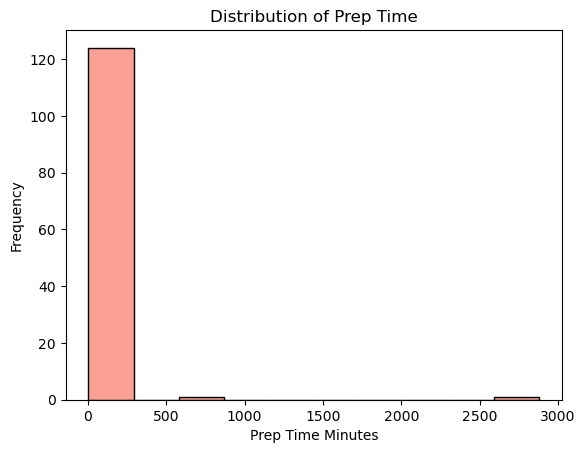

In [173]:
sns.histplot(recipes['Prep Time (Minutes)'], bins = 10, color = 'salmon', edgecolor = 'black')
plt.title("Distribution of Prep Time")
plt.xlabel("Prep Time Minutes")
plt.ylabel("Frequency")
plt.show()

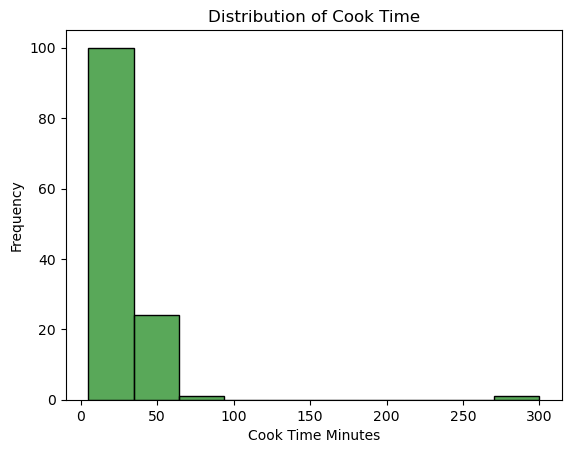

In [174]:
sns.histplot(recipes['Cook Time (Minutes)'], bins = 10, color = 'forestgreen', edgecolor = 'black')
plt.title("Distribution of Cook Time")
plt.xlabel("Cook Time Minutes")
plt.ylabel("Frequency")
plt.show()

The distributions appear pretty similar, with most of the observations falling below 100 minutes for both the preparation and cooking times. Only a small number of outliers lie all the way to the right of the plot/distribution, indicating that most of the recipes within this dataset do not experience a prep time of more than 250 minutes nor a cooking time of more than 100 minutes.

### part 3)

Now, it might be useful to cluster our data. Let's observe again what variables are included in our dataset.

In [175]:
recipes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 0 to 148
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Dish Name            126 non-null    object 
 1   Description          126 non-null    object 
 2   Spice                126 non-null    object 
 3   Prep Time            126 non-null    object 
 4   Views                126 non-null    int64  
 5   Rating               126 non-null    float64
 6   Number of Votes      126 non-null    float64
 7   Serves               126 non-null    float64
 8   Dietary Info         126 non-null    object 
 9   Cook Time            126 non-null    object 
 10  Num_Ingredients      126 non-null    int64  
 11  Num_Instructions     126 non-null    int64  
 12  Prep Time (Minutes)  126 non-null    int64  
 13  Cook Time (Minutes)  126 non-null    int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 14.8+ KB


For clustering, the columns that will serve us the best are the numerical ones. Additionally, columns with a small number of unique values (such as "Spice" and "Dietary Info") can be converted into dummy variables using encoding. Let's start with encoding them:

In [176]:
recipes = pd.get_dummies(recipes, columns=['Dietary Info'], drop_first=True, dtype=int)

Because "Spice" follows an inherent order, label encoding is of better use than the Pandas get_dummmies() function. 

In [177]:
label_encoder = LabelEncoder()
recipes['Spice'] = label_encoder.fit_transform(recipes['Spice'])

Therefore, of the variables in our dataset, we will utilize everything but the name of the dish, the description of the dish, and the prep/cook time (considering we created new columns with just the numerical values).

In [178]:
features = recipes.drop(columns = ['Dish Name', 'Description', 'Prep Time', 'Cook Time'])

Because the data columns are all being measured with various scales, it is extremely important that we standardize the data using StandardScaler().

In [179]:
scaler = StandardScaler()
features = scaler.fit_transform(features)

The most commonly used form of clustering is known as K-means, which groups data points into a specified number of clusters where each point belongs to a cluster with the closest mean. This partitioning of the data minimizes the variance within each cluster. In K-means clustering, there are two types of techniques often used to determine the optimal number of clusters. We will utilize the elbow method, which plots the sum of the squared distances of the data points to their nearest centroid (mean) against the number of clusters. It is easy to interpret and visualize, as well as computationally inexpensive. Additionally, we should observe the silhouette score, which evaluates the quality of the clustering by measuring how similar each point is to its own cluster compared to other clusters. This score ranges from -1 to +1, with a higher score translating to better-defined cluster and scores close to 0 specifying that the clusters are poorly defined. Negative values indicate that the samples may be misclassified.

In [180]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

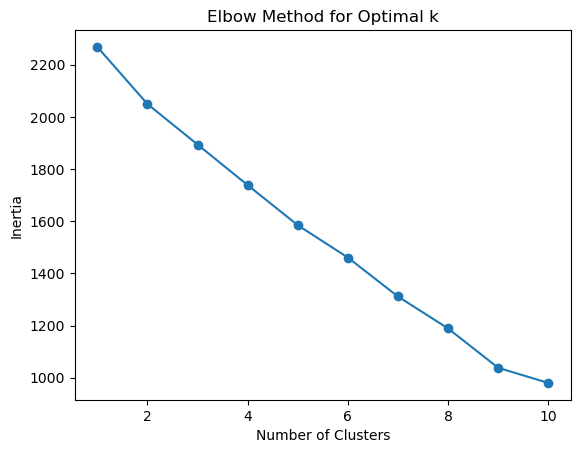

In [181]:
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

From this plot, it is not very clear where the inertia starts to decrease at a slower rate. Therefore, we should also use the silhouette score to determine the optimal number of clusters.

In [182]:
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, n_init = 50, random_state = 42)
    kmeans.fit(features)
    silhouette_avg = silhouette_score(features, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

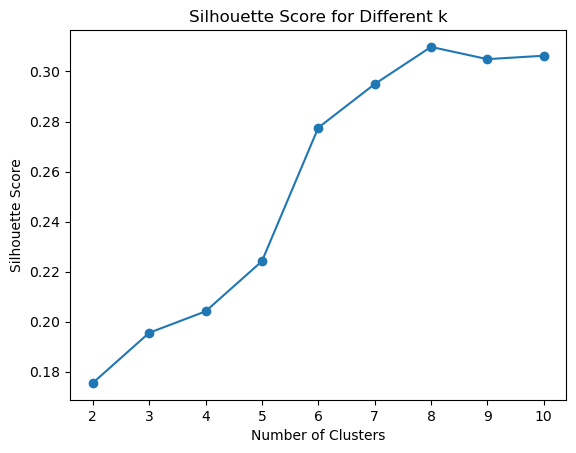

In [183]:
plt.plot(range(2, 11), silhouette_scores, marker = 'o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Based on the silhouette score, the optimal number of clusters for our data is eight. We may now use this number to fit our K-means model:

In [184]:
optimal_k = 8
kmeans = KMeans(n_clusters = optimal_k, random_state=42, n_init = 20)
recipes['cluster'] = kmeans.fit_predict(features)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


To visualize these results, we should use Principal Component Analysis (PCA), which identifies the most relevant features with the most variance; the principal components are linear combinations of the original variables, but they are now uncorrelated. The component with the most variance is represented along the x-axis, while the component with the second-most variance is represented along the y-axis.

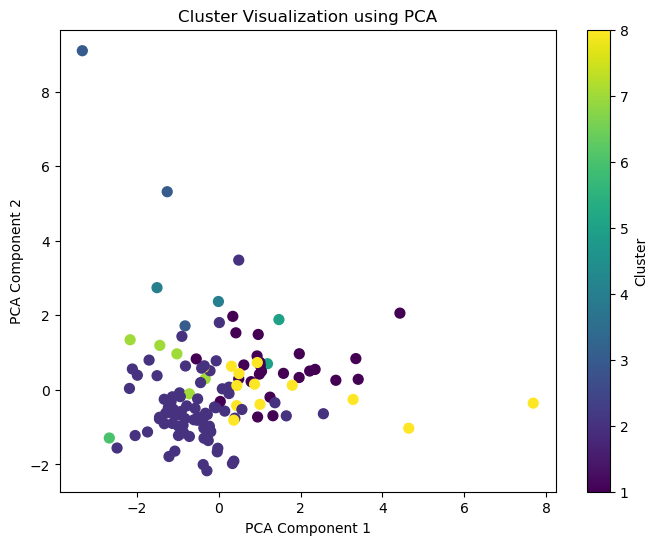

In [185]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(features)

recipes['cluster'] = recipes['cluster'] +1

plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=recipes['cluster'], cmap='viridis', s=50)
plt.title('Cluster Visualization using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

From this, we see that the clustering process could've performed better. While some of the clusters are very obvious (purple vs. green vs. blue vs. yellow), there is a significant amount of overlap amongst the data points. It is difficult to distinguish where the centroids are due to the overlap, indicating that some adjustment could be made toward the selected features, potentially improving how separated our clusters are.

### part 4)

Finally, we would like to run predictions on the 'Rating' variable using both a Random Forest classifier and XGBoost classification. We can follow the same process we did previously, where we removed the 'Dish Name' and 'Description' varibles, as well as converted the necessary variables into dummies. 

In [186]:
y = recipes['Rating']
X = recipes.drop(columns = ['Dish Name', 'Description', 'Rating', 'Prep Time', 'Cook Time', 'cluster'])

Split the data into training and testing:

In [187]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Fit a Random Forest model:

In [188]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")

Best Random Forest parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}


In [189]:
rf_best = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)

In [190]:
mse_rf_best = mean_squared_error(y_test, y_pred_rf_best)
print(f"Tuned Random Forest MSE: {mse_rf_best:.5f}")

Tuned Random Forest MSE: 0.11048


Therefore, after obtaining the best parameters for our model and applying them to fit our data, we get a mean-squared error of about 0.11, which is remarkably low. Now, we should observe the variable importance:

In [191]:
rf_sorted = sorted(zip(X.columns, rf_best.feature_importances_), key=lambda x: x[1], reverse=True)

print("Random Forest Feature Importances:")
for feat, imp in rf_sorted:
    print(feat, imp)

Random Forest Feature Importances:
Number of Votes 0.4692206063320467
Views 0.1934416334675514
Num_Ingredients 0.13909204493892524
Num_Instructions 0.07087741744196088
Prep Time (Minutes) 0.04177415853288877
Dietary Info_VEGETARIAN 0.024649986799577722
Cook Time (Minutes) 0.024245209673361596
Spice 0.022436074395643837
Serves 0.011777555244022108
Dietary Info_LACTOSE-FREE 0.0024853131740218072
Dietary Info_CONTAINS-NUTS 0.0
Dietary Info_DAIRY-FREE 0.0
Dietary Info_GLUTEN-FREE 0.0
Dietary Info_HEALTHY 0.0
Dietary Info_LOW-CALORIES 0.0
Dietary Info_No Dietary Info 0.0
Dietary Info_WHEAT-FREE 0.0


From this, we see that 'Number of Votes', 'Views', and 'Num_Ingredients' are the most important variables for our random forest model. Many of the dummy variables concerning 'Dietary Info' are not important at all, excluding the 'Vegetarian' option.

Now, let's fit an XGBoost model:

In [192]:
xgb_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 10],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_grid = GridSearchCV(XGBRegressor(objective="reg:squarederror", random_state=42), xgb_params, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost parameters: {xgb_grid.best_params_}")

Best XGBoost parameters: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [193]:
xgb_best = XGBRegressor(**xgb_grid.best_params_, objective="reg:squarederror", random_state=42)
xgb_best.fit(X_train, y_train)
y_pred_xgb_best = xgb_best.predict(X_test)

In [194]:
mse_xgb_best = mean_squared_error(y_test, y_pred_xgb_best)
print(f"Tuned XGBoost MSE: {mse_xgb_best:.5f}")

Tuned XGBoost MSE: 0.24349


Therefore, after obtaining the best parameters for our XGBoost model and applying them to fit our data, we get a mean-squared error of about 0.25, which is somewhat higher than the MSE we got with Random Forest. Both models performed fairly well, but our goal is have a lower MSE (difference between actual and predicted values), telling us that the Random Forest model is superior. 

Observing feature importance for XGBoost model:

In [195]:
xgb_sorted = sorted(zip(X.columns, xgb_best.feature_importances_), key=lambda x: x[1], reverse=True)

print("XGBoost Feature Importances:")
for feat, imp in xgb_sorted:
    print(feat, imp)

XGBoost Feature Importances:
Number of Votes 0.5107272
Prep Time (Minutes) 0.21044257
Num_Ingredients 0.16185685
Views 0.116973385
Spice 0.0
Serves 0.0
Num_Instructions 0.0
Cook Time (Minutes) 0.0
Dietary Info_CONTAINS-NUTS 0.0
Dietary Info_DAIRY-FREE 0.0
Dietary Info_GLUTEN-FREE 0.0
Dietary Info_HEALTHY 0.0
Dietary Info_LACTOSE-FREE 0.0
Dietary Info_LOW-CALORIES 0.0
Dietary Info_No Dietary Info 0.0
Dietary Info_VEGETARIAN 0.0
Dietary Info_WHEAT-FREE 0.0


In comparison to the feature importance of the Random Forest model, 'Number of Votes' is still the feature with the highest importance. Interestingly, 'Prep Time (Minutes)' follows afterward, a different result than what we obtained in the RF model. Additionally, we see that 'Num_Ingredients' and 'Views' are the third and fourth highest important features in the XGBoost model, so they are not ranked too differently from where we saw them in the Random Forest model. However, in our XGBoost model, none of the remaining features have any importance.

All in all, 'Prep Time (Minutes)' being valued more highly by XGBoost demonstrates a model-specific difference. Both models identify a small set of features that drive predictions, with variations in their importance rankings — a sign that model-specific strategies influence which patterns are extracted from the data.